[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter17_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 17: Bubbles and Crashes

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: pen and paper (A1–A8); Part B: estimation and inference (B1–B8); Part C: open question.

> The solutions are discussed in the seminar.

In [ ]:
# On Colab: !pip install xlrd
import io
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import optimize, stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
Teal     = '#17A2B8'
Magenta  = '#D63384'
Brown    = '#795548'

HERE = '.'
SEED = 42
R_MC = 2000
RECOMPUTE = False   # True: recalculeaza indicatorii LPPLS (cateva minute); False: ii citeste din fisierele publicate
QL_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_17/'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend(fig, axes, ncol=3, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    h, l = [], []
    for ax in np.atleast_1d(axes):
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l and not ll.startswith('_'):
                h.append(hh)
                l.append(ll)
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer, np.bool_)):
        return o.item()
    if isinstance(o, pd.Timestamp):
        return str(o.date())
    return o


def yrs(idx):
    """Data -> ani zecimali."""
    idx = pd.DatetimeIndex(idx)
    return np.asarray(idx.year + (idx.dayofyear - 1) / 365.25)


def todate(x):
    """Ani zecimali -> data."""
    y = int(np.floor(x))
    return pd.Timestamp(f'{y}-01-01') + pd.Timedelta(days=float((x - y) * 365.25))


def d2s(d):
    return None if d is None else str(pd.Timestamp(d).date())


import shutil
import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder
# published LPPLS indicators: local copy if the notebook runs inside the repository
for _d in ('.', os.path.join('..', 'Quantlets', 'Ch_17'), os.path.join('..', '..', 'Quantlets', 'Ch_17')):
    for _f in ('ch17_lppls_ci_btc.csv', 'ch17_lppls_ci_ndx.csv'):
        if os.path.exists(os.path.join(_d, _f)) and not os.path.exists(os.path.join(HERE, _f)):
            shutil.copy(os.path.join(_d, _f), HERE)


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026 (Nasdaq 100, S&P 500, BET, BET-FI, Bitcoin, Ethereum, Dogecoin, NVIDIA, Cisco, Tesla, GameStop, Strategy).
- Weekly and monthly series: last close of the week or month; stocks adjusted for dividends and splits.
- S&P Composite monthly since 1871 (Robert J. Shiller); 49 US industry portfolios (Kenneth French Data Library).

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, eticheta, tip, coloana, data de start)
MARKETS = {
    'sp500': ('GSPC.INDX',   'S&P 500',        'index',  'close',          '1990-01-01'),
    'ndx':   ('NDX.INDX',    'Nasdaq 100',     'index',  'close',          '1990-01-01'),
    'bet':   ('BET',         'BET',            'index',  'close',          '1997-09-19'),
    'betfi': ('BETFI.INDX',  'BET-FI',         'index',  'close',          '2012-01-25'),
    'btc':   ('BTC-USD.CC',  'Bitcoin',        'crypto', 'close',          '2014-09-17'),
    'eth':   ('ETH-USD.CC',  'Ethereum',       'crypto', 'close',          '2016-01-01'),
    'doge':  ('DOGE-USD.CC', 'Dogecoin',       'crypto', 'close',          '2017-01-01'),
    'nvda':  ('NVDA.US',     'NVIDIA',         'stock',  'adjusted_close', '1999-01-22'),
    'csco':  ('CSCO.US',     'Cisco Systems',  'stock',  'adjusted_close', '1990-02-16'),
    'tsla':  ('TSLA.US',     'Tesla',          'stock',  'adjusted_close', '2010-06-29'),
    'gme':   ('GME.US',      'GameStop',       'stock',  'adjusted_close', '2002-02-13'),
    'mstr':  ('MSTR.US',     'Strategy (MicroStrategy)', 'stock', 'adjusted_close', '1998-06-11'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

SHILLER_URLS = ['https://img1.wsimg.com/blobby/go/e5e77e0b-59d1-44d9-ab25-4763ac982e53/downloads/ie_data.xls',
                'http://www.econ.yale.edu/~shiller/data/ie_data.xls']
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(name, freq='D', start=None, end=END):
    """Nivelul seriei: 'D' zilnic (curatat), 'W' ultimul pret al saptamanii, 'M' ultimul pret al lunii."""
    symbol, _, kind, col, start0 = MARKETS[name]
    s = read_market(symbol)[col].loc[start or start0:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]          # fara cotatii de weekend
    if kind == 'index':
        s = s[s.diff() != 0]                  # fara sarbatori completate cu pretul anterior
    if freq == 'W':
        s = s.resample('W-FRI').last().dropna()
    elif freq == 'M':
        s = s.resample('ME').last().dropna()
    return s.rename(name)


def shiller():
    """S&P Composite lunar (Shiller): pret real, dividend real si raportul pret/dividend (P/D)."""
    if 'shiller' in _CACHE:
        return _CACHE['shiller']
    raw = None
    for url in SHILLER_URLS:
        try:
            raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                         timeout=120).read()
            break
        except Exception:
            continue
    d = pd.read_excel(io.BytesIO(raw), sheet_name='Data', header=None, skiprows=8)
    d = d.iloc[:, [0, 1, 2, 7, 8]]
    d.columns = ['date', 'P', 'D', 'real_P', 'real_D']
    d = d[pd.to_numeric(d['date'], errors='coerce').notna()].copy()
    yr = d['date'].astype(float)
    year = np.floor(yr + 1e-9).astype(int)
    month = np.round((yr - year) * 100).astype(int)
    d.index = pd.to_datetime(dict(year=year, month=month, day=1)) + pd.offsets.MonthEnd(0)
    d = d[['P', 'D', 'real_P', 'real_D']].apply(pd.to_numeric, errors='coerce').dropna()
    d['PD'] = d['real_P'] / d['real_D']
    _CACHE['shiller'] = d
    return d


def _french_table(fname):
    """Primul tabel lunar (YYYYMM) dintr-un fisier Kenneth French, in zecimal."""
    raw = urllib.request.urlopen(urllib.request.Request(FRENCH + fname, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    text = zipfile.ZipFile(io.BytesIO(raw)).read(zipfile.ZipFile(io.BytesIO(raw)).namelist()[0]).decode('latin-1')
    lines = text.splitlines()
    i = next(k for k, l in enumerate(lines) if l.startswith(',') and len(l.split(',')) > 1)
    cols = [c.strip() for c in lines[i].split(',')[1:]]
    rows = []
    for l in lines[i + 1:]:
        parts = [x.strip() for x in l.split(',')]
        if not parts or len(parts[0]) != 6 or not parts[0].isdigit():
            break
        rows.append([parts[0]] + [float(x) for x in parts[1:]])
    df = pd.DataFrame(rows, columns=['date'] + cols)
    df['date'] = pd.to_datetime(df['date'], format='%Y%m') + pd.offsets.MonthEnd(0)
    return df.set_index('date').replace([-99.99, -999.0], np.nan) / 100.0


def industries():
    """49 de industrii (randamente lunare ponderate cu valoarea) si randamentul pietei (Mkt-RF + RF)."""
    if 'ind' in _CACHE:
        return _CACHE['ind']
    ind = _french_table('49_Industry_Portfolios_CSV.zip')
    ff = _french_table('F-F_Research_Data_Factors_CSV.zip')
    mkt = (ff['Mkt-RF'] + ff['RF']).rename('MKT')
    _CACHE['ind'] = (ind, mkt)
    return ind, mkt

## Explosiveness tests, LPPLS and drawdowns

- `psy`, `psy_cv`, `wild_cv`, `episodes`: right-tailed ADF, SADF, GSADF, BSADF, Monte Carlo and wild bootstrap critical values, date-stamping.
- `lppls_fit`, `lppls_qualified`, `lppls_confidence`: LPPLS calibration (Filimonov–Sornette), filter, confidence indicator.

In [ ]:
def _cums(y):
    """Sume cumulate pentru regresia Delta y_t = a + b y_{t-1} (randurile t = 1..n); y poate fi (n+1,) sau (R, n+1)."""
    y = np.atleast_2d(np.asarray(y, float))
    x, z = y[:, :-1], np.diff(y, axis=1)
    pad = lambda a: np.concatenate([np.zeros((a.shape[0], 1)), np.cumsum(a, axis=1)], axis=1)
    return pad(x), pad(x * x), pad(z), pad(z * z), pad(x * z)


def _adf_end(C, e, s):
    """Statistica t a lui b pentru ferestrele [s, e] (s vector), pe toate replicile (randurile lui C)."""
    Sx, Sxx, Sz, Szz, Sxz = (c[:, e + 1][:, None] - c[:, s] for c in C)
    n = (e + 1 - s).astype(float)
    den = n * Sxx - Sx ** 2
    b = (n * Sxz - Sx * Sz) / den
    a = (Sz - b * Sx) / n
    ssr = np.maximum(Szz - a * Sz - b * Sxz, 1e-300)
    return b / np.sqrt(ssr / (n - 2) * n / den)


def adf_stat(y):
    """ADF la dreapta pe intreaga serie (fara lag-uri)."""
    C = _cums(y)
    n = len(y) - 1
    return float(_adf_end(C, n - 1, np.array([0]))[0, 0])


def min_window(T, r0=None):
    """Fereastra minima PSY: r0 = 0.01 + 1.8 / sqrt(T)."""
    r0 = 0.01 + 1.8 / np.sqrt(T) if r0 is None else r0
    return int(np.floor(r0 * T)), r0


def psy(y, r0=None):
    """ADF, SADF, GSADF si sirurile BSADF (sup pe inceputuri) si ADF recursiv (PWY) pentru y (log-nivel)."""
    y = np.asarray(y, float)
    n = len(y) - 1                                  # numarul de randuri de regresie
    w0, r0 = min_window(n, r0)
    C = _cums(y)
    bsadf = np.full(n, np.nan)
    fwd = np.full(n, np.nan)
    for e in range(w0 - 1, n):
        s = np.arange(0, e - w0 + 2)
        st = _adf_end(C, e, s)[0]
        bsadf[e] = st.max()
        fwd[e] = st[0]
    return dict(adf=float(fwd[-1]), sadf=float(np.nanmax(fwd)), gsadf=float(np.nanmax(bsadf)),
                bsadf=bsadf, fwd=fwd, w0=w0, r0=r0, n=n)


def _null_paths(T, R, rng):
    """Mers aleator cu drift slab (PSY 2015): y_t = T^{-1} + y_{t-1} + e_t, e_t ~ N(0, 1)."""
    e = rng.standard_normal((R, T))
    return np.concatenate([np.zeros((R, 1)), np.cumsum(1.0 / T + e, axis=1)], axis=1)


def _bsadf_paths(Y, w0, chunk=100):
    """Sirurile BSADF si ADF recursiv pentru mai multe traiectorii (randurile lui Y)."""
    R, n = Y.shape[0], Y.shape[1] - 1
    bs = np.full((R, n), np.nan)
    fw = np.full((R, n), np.nan)
    for i in range(0, R, chunk):
        C = _cums(Y[i:i + chunk])
        for e in range(w0 - 1, n):
            st = _adf_end(C, e, np.arange(0, e - w0 + 2))
            bs[i:i + chunk, e] = st.max(axis=1)
            fw[i:i + chunk, e] = st[:, 0]
    return bs, fw


def psy_cv(T, w0, R=1000, seed=42, q=(0.90, 0.95, 0.99)):
    """Valori critice Monte Carlo: ADF, SADF, GSADF (cuantile) si sirurile BSADF / ADF recursiv la 95%."""
    rng = np.random.default_rng(seed)
    bs, fw = _bsadf_paths(_null_paths(T, R, rng), w0)
    out = dict(T=T, w0=w0, R=R,
               adf={f'{int(100 * a)}': float(np.quantile(fw[:, -1], a)) for a in q},
               sadf={f'{int(100 * a)}': float(np.quantile(np.nanmax(fw, axis=1), a)) for a in q},
               gsadf={f'{int(100 * a)}': float(np.quantile(np.nanmax(bs, axis=1), a)) for a in q})
    out['bsadf95'] = np.nanquantile(bs, 0.95, axis=0)
    out['fwd95'] = np.nanquantile(fw, 0.95, axis=0)
    out['null'] = dict(adf=fw[:, -1], sadf=np.nanmax(fw, axis=1), gsadf=np.nanmax(bs, axis=1))
    return out


def wild_cv(y, w0, R=500, seed=42):
    """Wild bootstrap (semne Rademacher pe Delta y, fara drift): sirul BSADF la 95% si GSADF la 95%."""
    rng = np.random.default_rng(seed)
    dy = np.diff(np.asarray(y, float))
    dy = dy - dy.mean()
    W = rng.choice([-1.0, 1.0], size=(R, len(dy)))
    Y = np.concatenate([np.zeros((R, 1)), np.cumsum(W * dy, axis=1)], axis=1)
    bs, _ = _bsadf_paths(Y, w0)
    return dict(bsadf95=np.nanquantile(bs, 0.95, axis=0), gsadf95=float(np.quantile(np.nanmax(bs, axis=1), 0.95)))


def episodes(stat, cv, index, min_len):
    """Episoade in care stat > cv cel putin min_len perioade: (inceput, sfarsit) datat in timp real."""
    above = np.asarray(stat > cv)
    above[np.isnan(stat) | np.isnan(cv)] = False
    out, i, n = [], 0, len(above)
    while i < n:
        if above[i]:
            j = i
            while j + 1 < n and above[j + 1]:
                j += 1
            if j - i + 1 >= min_len:
                out.append((index[i], index[j] if j + 1 < n else None, j - i + 1))
            i = j + 1
        else:
            i += 1
    return out


# =============================================================================
# BULE RATIONALE SIMULATE
# =============================================================================
def blanchard_watson(T=400, r=0.01, pi=0.97, b0=1.0, sd=0.5, seed=7):
    """Bula Blanchard-Watson: supravietuieste cu prob. pi si creste cu (1+r)/pi, altfel revine la zgomot."""
    rng = np.random.default_rng(seed)
    b = np.empty(T)
    b[0] = b0
    for t in range(1, T):
        eps = sd * rng.standard_normal()
        b[t] = (1 + r) / pi * b[t - 1] + eps if rng.random() < pi else eps
    return b


def evans_bubble(T=400, r=0.02, alpha=1.0, delta=0.5, pi=0.85, seed=11):
    """Bula care se prabuseste periodic (Evans 1991): creste cu (1+r) sub alpha, apoi explodeaza sau revine la delta."""
    rng = np.random.default_rng(seed)
    u = np.exp(rng.normal(-0.005, 0.07, T))       # u_t > 0, E[u_t] ~ 1
    B = np.empty(T)
    B[0] = delta
    for t in range(1, T):
        if B[t - 1] <= alpha:
            B[t] = (1 + r) * B[t - 1] * u[t]
        else:
            theta = rng.random() < pi
            B[t] = (delta + (1 + r) / pi * (B[t - 1] - delta / (1 + r)) * theta) * u[t]
    return B


# =============================================================================
# LPPLS (Johansen-Ledoit-Sornette, calibrarea Filimonov-Sornette 2013)
# =============================================================================
def lppls_linear(t, y, tc, m, w):
    """Pentru (tc, m, omega) dati: A, B, C1, C2 prin MCO si suma patratelor reziduurilor; dt = |tc - t|."""
    dt = np.abs(tc - t) + 1e-9
    f = dt ** m
    X = np.column_stack([np.ones_like(t), f, f * np.cos(w * np.log(dt)), f * np.sin(w * np.log(dt))])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    return beta, float(res @ res)


def _grid_ssr(t, y, tcs, ms, ws):
    """SSR pe o grila (tc, m, omega), vectorizat."""
    TC, M, W = (a.ravel() for a in np.meshgrid(tcs, ms, ws, indexing='ij'))
    dt = np.abs(TC[:, None] - t[None, :]) + 1e-9
    f = dt ** M[:, None]
    lg = np.log(dt)
    X = np.stack([np.ones_like(f), f, f * np.cos(W[:, None] * lg), f * np.sin(W[:, None] * lg)], axis=2)
    XtX = np.einsum('gni,gnj->gij', X, X) + 1e-10 * np.eye(4)
    Xty = np.einsum('gni,n->gi', X, y)
    beta = np.linalg.solve(XtX, Xty[..., None])[..., 0]
    ssr = y @ y - np.einsum('gi,gi->g', beta, Xty)
    return TC, M, W, ssr


LPPLS_SEARCH = dict(tc=(-0.2, 0.5), m=(0.01, 0.99), w=(2.0, 25.0))
LPPLS_FILTER = dict(tc=(-0.05, 0.1), m=(0.01, 0.99), w=(2.0, 15.0), osc=2.5, damping=0.5)


def lppls_fit(t, y, tc_rng=LPPLS_SEARCH['tc'], m_rng=LPPLS_SEARCH['m'], w_rng=LPPLS_SEARCH['w'], refine=True):
    """Calibrare LPPLS pe fereastra (t, y), t in ani: grila pe (tc, m, omega) + rafinare Nelder-Mead.
    tc cauta in [t2 + tc_rng[0] * D, t2 + tc_rng[1] * D], D = t2 - t1 (Filimonov-Sornette 2013)."""
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    t1, t2 = t[0], t[-1]
    D = t2 - t1
    lo = np.array([t2 + tc_rng[0] * D, m_rng[0], w_rng[0]])
    hi = np.array([t2 + tc_rng[1] * D, m_rng[1], w_rng[1]])
    TC, M, W, ssr = _grid_ssr(t, y, np.linspace(lo[0], hi[0], 21), np.linspace(lo[1], hi[1], 10),
                              np.linspace(lo[2], hi[2], 12))
    k = int(np.argmin(ssr))
    x0 = np.array([TC[k], M[k], W[k]])
    if refine:
        obj = lambda p: lppls_linear(t, y, *np.clip(p, lo, hi))[1]
        r = optimize.minimize(obj, x0, method='Nelder-Mead', options=dict(xatol=1e-5, fatol=1e-9, maxiter=800))
        x0 = np.clip(r.x, lo, hi)
    tc, m, w = x0
    (A, B, C1, C2), s = lppls_linear(t, y, tc, m, w)
    C = np.hypot(C1, C2)
    return dict(tc=float(tc), m=float(m), w=float(w), A=float(A), B=float(B), C1=float(C1), C2=float(C2),
                C=float(C), ssr=float(s), rmse=float(np.sqrt(s / len(t))),
                damping=float(m * abs(B) / (w * C)) if C > 0 else np.inf,
                osc=float(w / (2 * np.pi) * np.log(abs((tc - t1) / (tc - t2)))),
                t1=float(t1), t2=float(t2))


def lppls_path(fit, t):
    """Traiectoria LPPLS ajustata (log-pret)."""
    dt = np.abs(fit['tc'] - np.asarray(t, float)) + 1e-9
    f = dt ** fit['m']
    return fit['A'] + fit['B'] * f + f * (fit['C1'] * np.cos(fit['w'] * np.log(dt)) + fit['C2'] * np.sin(fit['w'] * np.log(dt)))


def lppls_qualified(fit, flt=LPPLS_FILTER):
    """Filtrul de calificare: bula pozitiva (B < 0), m si omega in interval, tc aproape de t2, oscilatii, amortizare."""
    D = fit['t2'] - fit['t1']
    return bool(fit['B'] < 0 and flt['m'][0] <= fit['m'] <= flt['m'][1] and flt['w'][0] <= fit['w'] <= flt['w'][1]
                and fit['t2'] + flt['tc'][0] * D <= fit['tc'] <= fit['t2'] + flt['tc'][1] * D
                and fit['osc'] >= flt['osc'] and fit['damping'] >= flt['damping'])


def lppls_confidence(t, y, t2_idx, windows):
    """Indicatorul de incredere LPPLS la t2: ponderea ferestrelor [t2 - L, t2] (L in observatii) cu ajustari calificate."""
    q = []
    for L in windows:
        i1 = t2_idx - L
        if i1 < 0:
            continue
        f = lppls_fit(t[i1:t2_idx + 1], y[i1:t2_idx + 1], tc_rng=(-0.2, 0.2), refine=False)
        q.append(lppls_qualified(f))
    return float(np.mean(q)) if q else np.nan


# =============================================================================
# DRAWDOWN
# =============================================================================
def drawdown(p):
    """Scaderea fata de maximul anterior: p_t / max_{s<=t} p_s - 1."""
    return p / p.cummax() - 1

## Chapter helpers

In [ ]:
def _chg(y, s, e):
    """Variatia pretului pe durata episodului (de la inceputul la sfarsitul semnalului): > 0 crestere, < 0 prabusire."""
    e = y.index[-1] if e is None else e
    return float(np.exp(y.loc[e] - y.loc[s]) - 1)


def run_psy(y, R=R_MC, wild=False):
    """PSY complet pentru o serie log-nivel y (pd.Series): statistici, valori critice, episoade datate."""
    res = psy(y.values)
    cv = psy_cv(res['n'], res['w0'], R, SEED)
    L = int(np.ceil(np.log(res['n'])))
    idx = y.index[1:]
    ep = episodes(res['bsadf'], cv['bsadf95'], idx, L)
    ep_pwy = episodes(res['fwd'], cv['fwd95'], idx, L)
    out = dict(res=res, cv=cv, L=L, idx=idx, ep=ep, ep_pwy=ep_pwy)
    if wild:
        wc = wild_cv(y.values, res['w0'], 1000, SEED)
        out['wild'] = wc
        out['ep_wild'] = episodes(res['bsadf'], wc['bsadf95'], idx, L)
    return out


def summarise(o, y):
    """Rezumat JSON-abil al unei analize PSY."""
    r, cv = o['res'], o['cv']
    out = dict(T=r['n'], w0=r['w0'], r0=r['r0'], L=o['L'], adf=r['adf'], sadf=r['sadf'], gsadf=r['gsadf'],
               cv_adf=cv['adf'], cv_sadf=cv['sadf'], cv_gsadf=cv['gsadf'], start=d2s(y.index[0]), end=d2s(y.index[-1]),
               episodes=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep']],
               episodes_pwy=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep_pwy']],
               first_window_end=d2s(o['idx'][r['w0'] - 1]))
    if 'wild' in o:
        out['cv_gsadf_wild'] = o['wild']['gsadf95']
        out['episodes_wild'] = [dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in o['ep_wild']]
    return out


def _shade(ax, ep, end, y=None, alpha=0.25):
    """Episoadele datate: crestere (Amber) sau scadere accelerata (Teal)."""
    for s, e, _ in ep:
        up = True if y is None else _chg(y, s, e) > 0
        ax.axvspan(s, e if e is not None else end, color=Amber if up else Teal, alpha=alpha, lw=0)


def fig_psy(y, o, name, title, ylab, logscale=True, level=None, pwy=False, wild=False, level_label=None):
    """Doua panouri: nivelul seriei (cu episoadele datate) si BSADF fata de valoarea critica de 95%."""
    idx = o['idx']
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.4), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    lv = np.exp(y) if level is None else level
    axes[0].plot(lv.index, lv.values, color=MainBlue, lw=0.9, label=level_label or 'Level')
    if logscale:
        axes[0].set_yscale('log')
    axes[0].set_ylabel(ylab)
    axes[1].plot(idx, o['res']['bsadf'], color=IDAred, lw=0.9, label='BSADF statistic')
    axes[1].plot(idx, o['cv']['bsadf95'], color=Forest, lw=1.0, ls='--', label='95% critical value (Monte Carlo)')
    if wild:
        axes[1].plot(idx, o['wild']['bsadf95'], color=Purple, lw=1.0, ls='-.', label='95% critical value (wild bootstrap)')
    if pwy:
        axes[1].plot(idx, o['res']['fwd'], color=Teal, lw=0.8, label='Recursive ADF (start fixed, PWY)')
        axes[1].plot(idx, o['cv']['fwd95'], color=Orange, lw=0.9, ls=':', label='95% critical value of the recursive ADF')
    end = idx[-1]
    for ax in axes:
        _shade(ax, o['ep'], end, y)
    axes[1].set_ylabel('Statistic')
    axes[0].set_title(title, fontsize=9, loc='left')
    dirs = [_chg(y, s, e) > 0 for s, e, _ in o['ep']]
    if any(dirs):
        axes[1].fill_between([], [], color=Amber, alpha=0.25, label='Explosive episode, price rising')
    if not all(dirs):
        axes[1].fill_between([], [], color=Teal, alpha=0.25, label='Explosive episode, price falling')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig(name)


def real_time(o, p, win_years=2):
    """Pentru fiecare episod: primul semnal (timp real), varful pretului in episod si dupa, sfarsitul semnalului."""
    rows = []
    for s, e, n in o['ep']:
        e2 = e if e is not None else p.index[-1]
        seg = p.loc[s:e2 + pd.DateOffset(months=6)]
        pk = seg.idxmax()
        rows.append(dict(start=d2s(s), end=d2s(e), peak=d2s(pk), lead_days=int((pk - s).days),
                         change=float(p.loc[:e2].iloc[-1] / p.loc[:s].iloc[-1] - 1),
                         gain_to_peak=float(p.loc[pk] / p.loc[:s].iloc[-1] - 1),
                         dd_after=float((p.loc[pk:pk + pd.DateOffset(years=win_years)].min()) / p.loc[pk] - 1),
                         signal_end_after_peak_days=None if e is None else int((e - pk).days)))
    return rows


def signal_vs_peak(o, p, window, gap_days, dd_years=2):
    """Primul semnal al grupului de episoade care precede varful din fereastra data (timp real) vs varful."""
    pk = p.loc[window[0]:window[1]].idxmax()
    ep = sorted([(s, e if e is not None else p.index[-1]) for s, e, _ in o['ep'] if s <= pk])
    i = len(ep) - 1
    while i > 0 and (ep[i][0] - ep[i - 1][1]).days <= gap_days:
        i -= 1
    first = ep[i][0]
    p0 = p.loc[:first].iloc[-1]
    return dict(first=d2s(first), peak=d2s(pk), lead_days=int((pk - first).days), lead_months=float((pk - first).days / 30.44),
                gain=float(p.loc[pk] / p0 - 1), dd_after=float(p.loc[pk:pk + pd.DateOffset(years=dd_years)].min() / p.loc[pk] - 1),
                signal_end=d2s(ep[-1][1]) if ep[-1][1] != p.index[-1] else None)

## Seminar helpers

- Markov-switching fits, the confidence-indicator evaluation and the published indicator windows.

In [ ]:
A3_Y = [4.6, 4.62, 4.66, 4.71, 4.79, 4.9, 5.05, 5.25]
CI_WINDOWS = [90, 150, 210, 270, 330, 390, 450, 510, 570, 630, 690]


def ms_fit(key, start, freq='W', k=2):
    """Markov-switching: medie si dispersie diferite pe regim, randamente log saptamanale in %."""
    import statsmodels.api as sm
    p = price(key, freq, start)
    r = 100 * np.log(p).diff().dropna()
    res = sm.tsa.MarkovRegression(r, k_regimes=k, trend='c', switching_variance=True).fit(search_reps=20, disp=False)
    hi = int(np.argmax([res.params[f'sigma2[{j}]'] for j in range(k)]))
    return p, r, res, hi


def ms_summary(res, hi, r, k=2):
    par = res.params
    se = res.bse
    lo = 1 - hi if k == 2 else None
    P = np.asarray(res.regime_transition)[:, :, 0]         # P[i, j] = P(s_t = i | s_{t-1} = j)
    out = dict(n=int(len(r)), start=d2s(r.index[0]), end=d2s(r.index[-1]), llf=float(res.llf), aic=float(res.aic),
               bic=float(res.bic))
    for j, tag in [(lo, 'calm'), (hi, 'turb')]:
        out[tag] = dict(mu=float(par[f'const[{j}]']), mu_se=float(se[f'const[{j}]']),
                        sd=float(np.sqrt(par[f'sigma2[{j}]'])), stay=float(P[j, j]),
                        dur=float(res.expected_durations[j]), share=float(res.smoothed_marginal_probabilities[j].mean()))
    return out


def ci_evaluation(ci, p, horizon=90, fall=0.20):
    """Semnal (indicator > 0) vs o scadere de cel putin 20% sub pretul curent in urmatoarele 90 de zile."""
    rows = []
    for d, v in ci.items():
        fut = p.loc[d:d + pd.Timedelta(days=horizon)]
        rows.append(dict(date=d, ci=v, hit=bool(fut.min() / fut.iloc[0] - 1 <= -fall)))
    r = pd.DataFrame(rows)
    on, off = r[r.ci > 0], r[r.ci == 0]
    return dict(n=int(len(r)), n_on=int(len(on)), p_on=float(on.hit.mean()) if len(on) else None,
                p_off=float(off.hit.mean()), base=float(r.hit.mean()), horizon=horizon, fall=fall)


def _ms_step(P, mu, sd, prev_turb, r):
    """Un pas al filtrului Hamilton cu doua regimuri (0 = calm, 1 = turbulent)."""
    prev = np.array([1 - prev_turb, prev_turb])
    pred = P.T @ prev                          # P[i, j] = P(s_t = j | s_{t-1} = i)
    lik = stats.norm.pdf(r, mu, sd)
    post = pred * lik / (pred * lik).sum()
    return pred, lik, post


def _lppls_diag(t1, t2, tc, m, w, B, C1, C2):
    C = np.hypot(C1, C2)
    D = t2 - t1
    O = w / (2 * np.pi) * np.log((tc - t1) / (tc - t2))
    damp = m * abs(B) / (w * C)
    slope = -B * m * (tc - t2) ** (m - 1)          # d/dt [B (tc - t)^m] la t2, fara oscilatii
    return dict(C=C, D=D, O=O, damping=damp, dtc=tc - t2, dtc_days=(tc - t2) * 365.25, tc_lim=0.1 * D,
                slope=slope, m=m, w=w, B=B, ok_B=B < 0, ok_m=0.01 <= m <= 0.99, ok_w=2 <= w <= 15,
                ok_tc=tc - t2 <= 0.1 * D, ok_O=O >= 2.5, ok_D=damp >= 0.5)

## Part A — pen and paper

### A1. Fundamental value and a rational bubble [Solved]

- $D_1 = 2$, $g = 2\%$, $r = 6\%$, $P = 65$: fundamental value, bubble, and their paths over 5 and 30 years.

In [7]:
# Solution
def a1_present_value(D1=2.0, r=0.06, g=0.02, P=65.0):
    """Gordon: F = D1 / (r - g); bula B = P - F creste cu r, fundamentalul cu g."""
    F = D1 / (r - g)
    B = P - F
    out = dict(F=F, B=B, share0=B / P)
    for h in (5, 30):
        Fh, Bh = F * (1 + g) ** h, B * (1 + r) ** h
        out[f'F{h}'], out[f'B{h}'], out[f'share{h}'] = Fh, Bh, Bh / (Fh + Bh)
    return out


{k: round(v, 4) for k, v in a1_present_value().items()}

{'F': 50.0,
 'B': 15.0,
 'share0': 0.2308,
 'F5': 55.204,
 'B5': 20.0734,
 'share5': 0.2667,
 'F30': 90.5681,
 'B30': 86.1524,
 'share30': 0.4875}

### A2. A bubble that can burst [Proposed]

- Survival probability $\pi = 0.9$ per year: growth while alive, survival over 5 years, expected lifetime. Model: A1.

In [ ]:
# Your code here


### A3. Right-tailed ADF, step by step [Solved]

- Eight monthly log prices; $\hat b$, $\mathrm{SE}(\hat b)$, the ADF statistic and a simulated 95% critical value for 7 observations.

In [9]:
# Solution
def a3_adf(y=A3_Y, R=100_000):
    """ADF la dreapta pas cu pas: Delta y_t = a + b y_{t-1} + e_t; valoarea critica de 95% prin simulare (T = 7)."""
    y = np.asarray(y)
    x, z = y[:-1], np.diff(y)
    n = len(z)
    Sx, Sxx, Sz, Sxz, Szz = x.sum(), (x * x).sum(), z.sum(), (x * z).sum(), (z * z).sum()
    den = n * Sxx - Sx ** 2
    b = (n * Sxz - Sx * Sz) / den
    a = (Sz - b * Sx) / n
    res = z - a - b * x
    ssr = float(res @ res)
    s2 = ssr / (n - 2)
    se = np.sqrt(s2 * n / den)
    rng = np.random.default_rng(SEED)
    Y = np.cumsum(rng.standard_normal((R, n + 1)), axis=1)
    X, Z = Y[:, :-1], np.diff(Y, axis=1)
    sx, sxx, sz, sxz, szz = X.sum(1), (X * X).sum(1), Z.sum(1), (X * Z).sum(1), (Z * Z).sum(1)
    dd = n * sxx - sx ** 2
    bb = (n * sxz - sx * sz) / dd
    aa = (sz - bb * sx) / n
    tt = bb / np.sqrt((szz - aa * sz - bb * sxz) / (n - 2) * n / dd)
    return dict(n=n, Sx=Sx, Sxx=Sxx, Sz=Sz, Sxz=Sxz, Szz=Szz, xbar=Sx / n, zbar=Sz / n,
                Sxx_c=Sxx - Sx ** 2 / n, Sxz_c=Sxz - Sx * Sz / n, b=b, a=a, ssr=ssr, s2=s2, se=se, t=b / se,
                cv95=float(np.quantile(tt, 0.95)), cv99=float(np.quantile(tt, 0.99)))


{k: round(v, 5) for k, v in a3_adf().items()}

{'n': 7,
 'Sx': np.float64(33.33),
 'Sxx': np.float64(158.8607),
 'Sz': np.float64(0.65),
 'Sxz': np.float64(3.1585),
 'Szz': np.float64(0.0855),
 'xbar': np.float64(4.76143),
 'zbar': np.float64(0.09286),
 'Sxx_c': np.float64(0.16229),
 'Sxz_c': np.float64(0.06357),
 'b': np.float64(0.39173),
 'a': np.float64(-1.77232),
 'ssr': 0.00024,
 's2': 5e-05,
 'se': np.float64(0.01721),
 't': np.float64(22.76222),
 'cv95': 0.24212,
 'cv99': 1.12002}

### A4. How many windows? [Proposed]

- $T = 440$ months: minimum window, number of regressions in SADF and GSADF, minimum duration; the same for 10 years of daily data. Model: A3.

In [ ]:
# Your code here


### A5. Markov switching: durations and one filter step [Solved]

- $p_{11} = 0.98$, $p_{22} = 0.90$; update $P(\text{turbulent})$ after a return of $-6\%$.

In [11]:
# Solution
def a5_markov(P=((0.98, 0.02), (0.10, 0.90)), mu=(0.3, -0.5), sd=(2.0, 5.0), prev_turb=0.2, r=-6.0):
    P, mu, sd = np.array(P), np.array(mu), np.array(sd)
    dur = 1 / (1 - np.diag(P))
    pi_turb = P[0, 1] / (P[0, 1] + P[1, 0])
    pi = np.array([1 - pi_turb, pi_turb])
    m = pi @ mu
    v = pi @ (sd ** 2) + pi @ (mu - m) ** 2
    pred, lik, post = _ms_step(P, mu, sd, prev_turb, r)
    return dict(dur_calm=dur[0], dur_turb=dur[1], pi_calm=pi[0], pi_turb=pi[1], mean=m, var=v, sd=np.sqrt(v),
                pred_turb=pred[1], lik_calm=lik[0], lik_turb=lik[1], post_turb=post[1], r=r, prev=prev_turb)


{k: round(float(v), 5) for k, v in a5_markov().items()}

{'dur_calm': 50.0,
 'dur_turb': 10.0,
 'pi_calm': 0.83333,
 'pi_turb': 0.16667,
 'mean': 0.16667,
 'var': 7.58889,
 'sd': 2.75479,
 'pred_turb': 0.196,
 'lik_calm': 0.0014,
 'lik_turb': 0.04357,
 'post_turb': 0.88375,
 'r': -6.0,
 'prev': 0.2}

### A6. Another filter step [Proposed]

- $p_{11} = 0.95$, $p_{22} = 0.80$; a return of $+1\%$; probability two weeks ahead. Model: A5.

In [ ]:
# Your code here


### A7. Reading an LPPLS fit [Solved]

- Amplitude, number of oscillations, damping, the filter, the trend growth rate at $t_2$.

In [13]:
# Solution
def a7_lppls():
    return _lppls_diag(2025.0, 2026.0, 2026.08, 0.5, 8.0, -1.2, 0.06, -0.02)


a7_lppls()

{'C': np.float64(0.06324555320336758),
 'D': 1.0,
 'O': np.float64(3.3138474301831833),
 'damping': np.float64(1.1858541225631423),
 'dtc': 0.07999999999992724,
 'dtc_days': 29.219999999973425,
 'tc_lim': 0.1,
 'slope': 2.121320343560607,
 'm': 0.5,
 'w': 8.0,
 'B': -1.2,
 'ok_B': True,
 'ok_m': True,
 'ok_w': True,
 'ok_tc': True,
 'ok_O': np.True_,
 'ok_D': np.True_}

### A8. A fit that fails the filter [Proposed]

- $t_c = 2026.45$, $m = 0.95$, $\omega = 3.5$: which conditions fail? Model: A7.

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. GSADF on the S&P 500 price-dividend ratio [Solved]

- Three minimum windows ($r_0 = 0.03$, the PSY rule, $0.08$); date-stamped episodes.
- Interpretation: which episodes survive every window? Is every explosive episode a bubble?

In [15]:
# Solution
def b1_pd_windows(r0s=(0.03, None, 0.08)):
    """GSADF pe raportul P/D Shiller pentru trei ferestre minime (regula PSY in mijloc)."""
    sh = shiller()
    y = np.log(sh['PD'])
    out = []
    for r0 in r0s:
        res = psy(y.values, r0)
        cv = psy_cv(res['n'], res['w0'], 1000, SEED)
        L = int(np.ceil(np.log(res['n'])))
        ep = episodes(res['bsadf'], cv['bsadf95'], y.index[1:], L)
        out.append(dict(r0=res['r0'], w0=res['w0'], gsadf=res['gsadf'], cv95=cv['gsadf']['95'], cv99=cv['gsadf']['99'],
                        episodes=[dict(start=d2s(s), end=d2s(e), n=int(n), change=_chg(y, s, e)) for s, e, n in ep]))
    return out


pd.DataFrame(b1_pd_windows())

,r0,w0,gsadf,cv95,cv99,episodes
0,0.030000,55,3.934786,2.554293,3.019914,"[{'start': '1878-07-31', 'end': '1879-02-28', ..."
1,0.051951,95,3.411909,2.390324,2.896449,"[{'start': '1917-08-31', 'end': '1918-05-31', ..."
2,0.080000,147,1.773807,2.239278,2.783781,"[{'start': '1997-05-31', 'end': '2001-08-31', ..."


### B2. SADF vs GSADF [Proposed]

- Nasdaq 100 and S&P 500, monthly: PWY and PSY date-stamping. Model: B1.
- Interpretation: which episodes does only one method find?

In [ ]:
# Your code here


### B3. Bitcoin: simulated vs bootstrap critical values [Solved]

- Weekly log prices; Monte Carlo and wild bootstrap critical values; episodes under each.
- Interpretation: when are the bootstrap critical values higher, and why?

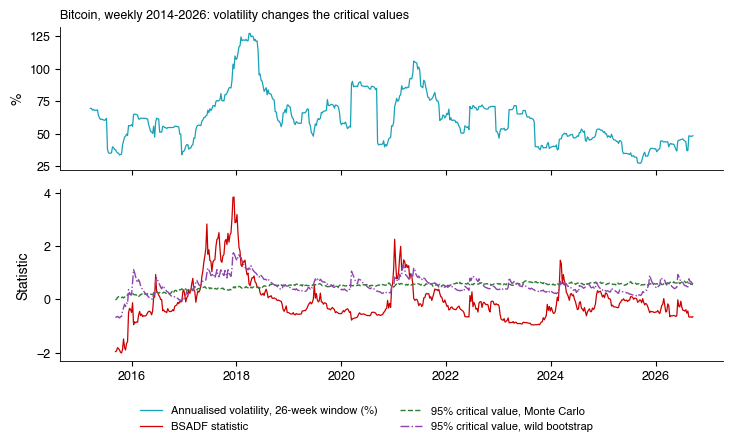

(3.848666319133873,
 {'90': 2.011965367670432, '95': 2.2705159532859884, '99': 2.6910831812657494},
 2.8225047174576106,
 [{'start': '2017-04-28',
   'end': '2018-06-08',
   'n': 59,
   'change': 4.791899637668441},
  {'start': '2020-12-25',
   'end': '2021-05-14',
   'n': 21,
   'change': 1.0223376264714514}],
 [{'start': '2017-05-05',
   'end': '2018-01-26',
   'n': 39,
   'change': 6.1821021192024235},
  {'start': '2020-12-25',
   'end': '2021-02-26',
   'n': 10,
   'change': 0.878781841154062}])

In [17]:
# Solution
def b3_btc_wild():
    """Bitcoin saptamanal: valori critice Monte Carlo (mers aleator gaussian) vs wild bootstrap."""
    y = np.log(price('btc', 'W'))
    o = run_psy(y, wild=True)
    idx = o['idx']
    dy = np.diff(y.values)
    vol = pd.Series(dy, index=idx).rolling(26).std() * np.sqrt(52)
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 4.0), sharex=True, gridspec_kw=dict(height_ratios=[1, 1.2]))
    axes[0].plot(vol.index, 100 * vol.values, color=Teal, lw=0.9, label='Annualised volatility, 26-week window (%)')
    axes[0].set_ylabel('%')
    axes[1].plot(idx, o['res']['bsadf'], color=IDAred, lw=0.9, label='BSADF statistic')
    axes[1].plot(idx, o['cv']['bsadf95'], color=Forest, lw=1.0, ls='--', label='95% critical value, Monte Carlo')
    axes[1].plot(idx, o['wild']['bsadf95'], color=Purple, lw=1.0, ls='-.', label='95% critical value, wild bootstrap')
    axes[1].set_ylabel('Statistic')
    axes[0].set_title('Bitcoin, weekly 2014-2026: volatility changes the critical values', fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=2, y=0.0)
    save_fig('ch17_sem_btc_wild')
    s = summarise(o, y)
    s['vol_first'] = float(vol.dropna().iloc[:52].mean())
    s['vol_last'] = float(vol.dropna().iloc[-52:].mean())
    s['wild_bs_max'] = float(np.nanmax(o['wild']['bsadf95']))
    s['mc_bs_max'] = float(np.nanmax(o['cv']['bsadf95']))
    return s


b3 = b3_btc_wild()
(b3['gsadf'], b3['cv_gsadf'], b3['cv_gsadf_wild'], b3['episodes'], b3['episodes_wild'])

### B4. The Bucharest Stock Exchange [Proposed]

- BET monthly and BET-FI weekly; Monte Carlo and wild bootstrap. Model: B1, B3.
- Interpretation: was 2003–2007 explosive in real time? Is the current rise explosive?

In [ ]:
# Your code here


### B5. How much does the critical time depend on the window? [Solved]

- Bitcoin, windows ending on 15 November 2017 with different starts; distribution of $t_c$.
- Interpretation: would you trust a single $t_c$ reported without its window?

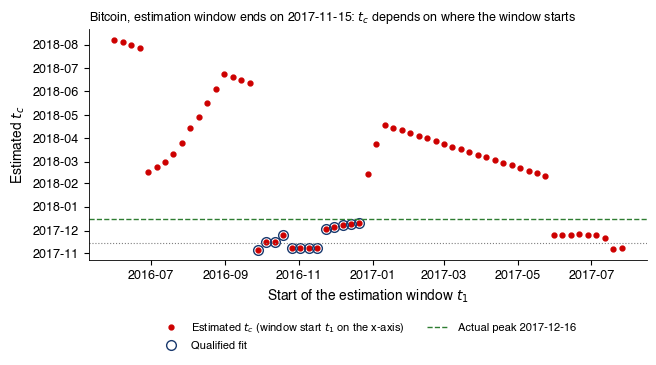

{'n': 61,
 't2': '2017-11-15',
 'peak': '2017-12-16',
 'tc_min': '2017-11-05',
 'tc_max': '2018-08-07',
 'tc_med': '2018-02-27',
 'iqr_days': 133.0,
 'share_q': 0.21311475409836064,
 'share_bound': 0.26229508196721313,
 'share_30': 0.2459016393442623,
 'med_err': 73.0}

In [19]:
# Solution
def b5_tc_windows(t2='2017-11-15', starts=('2016-06-01', '2017-08-01')):
    """LPPLS pe Bitcoin cu t2 fix si inceputul ferestrei t1 mobil (saptamanal): distributia lui tc."""
    p = price('btc', 'D')
    rows = []
    for t1 in pd.date_range(starts[0], starts[1], freq='7D'):
        w = p.loc[t1:t2]
        f = lppls_fit(yrs(w.index), np.log(w.values))
        rows.append(dict(t1=w.index[0], tc=todate(f['tc']), m=f['m'], w=f['w'], q=lppls_qualified(f),
                         at_bound=bool(f['m'] <= 0.011 or f['m'] >= 0.989 or f['w'] <= 2.01 or f['w'] >= 24.9)))
    d = pd.DataFrame(rows)
    pk = p.loc['2017'].idxmax()
    err = (d['tc'] - pk).dt.days
    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(d['t1'], d['tc'], 'o', color=IDAred, ms=3.5, label='Estimated $t_c$ (window start $t_1$ on the x-axis)')
    ax.plot(d.loc[d['q'], 't1'], d.loc[d['q'], 'tc'], 'o', mfc='none', mec=MainBlue, ms=7, label='Qualified fit')
    ax.axhline(pk, color=Forest, ls='--', lw=1.0, label=f'Actual peak {pk.date()}')
    ax.axhline(pd.Timestamp(t2), color=Gray, ls=':', lw=0.8)
    ax.set_xlabel('Start of the estimation window $t_1$')
    ax.set_ylabel('Estimated $t_c$')
    ax.set_title(f'Bitcoin, estimation window ends on {t2}: $t_c$ depends on where the window starts', fontsize=9, loc='left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch17_sem_tc_windows')
    return dict(n=int(len(d)), t2=t2, peak=d2s(pk), tc_min=d2s(d['tc'].min()), tc_max=d2s(d['tc'].max()),
                tc_med=d2s(d['tc'].sort_values().iloc[len(d) // 2]), iqr_days=float(np.subtract(*np.percentile(err, [75, 25]))),
                share_q=float(d['q'].mean()), share_bound=float(d['at_bound'].mean()),
                share_30=float((err.abs() <= 30).mean()), med_err=float(err.median()))


b5_tc_windows()

### B6. The confidence indicator on the Nasdaq 100 [Proposed]

- Published indicator 1997–2026; signal vs a 20% fall within 90 days. Model: B5.
- Interpretation: would it have helped an investor in 2000?

In [ ]:
# Your code here


### B7. Markov switching on the S&P 500 [Solved]

- Weekly log returns 1990–2026, two regimes; filtered vs smoothed probabilities.
- Interpretation: is the turbulent mean significantly negative? Why is the LR test non-standard?

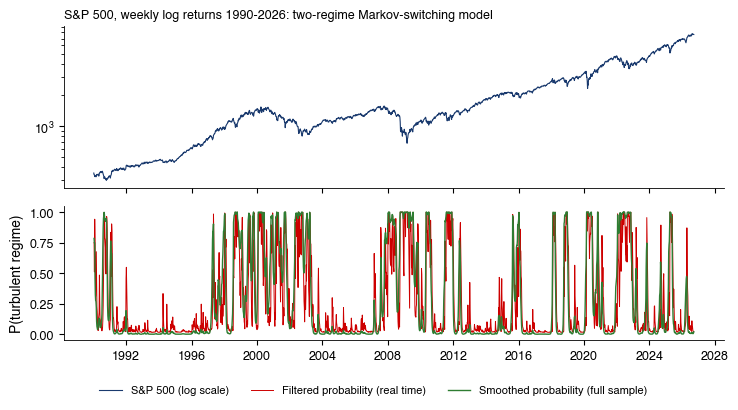

{'n': 1915,
 'start': '1990-01-12',
 'end': '2026-09-18',
 'llf': -4069.978818737957,
 'aic': 8151.957637475914,
 'bic': 8185.302474885603,
 'calm': {'mu': 0.3223690647249102,
  'mu_se': 0.04341727630512617,
  'sd': 1.486951667049898,
  'stay': 0.9737335841897786,
  'dur': 38.07142958617359,
  'share': 0.7266370872107705},
 'turb': {'mu': -0.268668144463811,
  'mu_se': 0.1721376487484457,
  'sd': 3.6742382253760955,
  'stay': 0.9306273006533584,
  'dur': 14.414892449307743,
  'share': 0.27336291278922253},
 'first_dotcom': '2000-01-28',
 'first_gfc': '2008-10-03',
 'first_covid': '2020-02-28',
 'share_turb_smoothed': 0.2558746736292428,
 'agree': 0.9007832898172323,
 'llf1': -4326.01626649381,
 'lr': 512.0748955117051}

In [21]:
# Solution
def b7_ms_sp():
    """Markov-switching cu doua regimuri pe S&P 500 saptamanal 1990-2026."""
    p, r, res, hi = ms_fit('sp500', '1990-01-01')
    out = ms_summary(res, hi, r)
    fp = res.filtered_marginal_probabilities[hi]
    sp = res.smoothed_marginal_probabilities[hi]
    fig, axes = plt.subplots(2, 1, figsize=(7.4, 3.8), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    axes[0].plot(p.index, p.values, color=MainBlue, lw=0.8, label='S&P 500 (log scale)')
    axes[0].set_yscale('log')
    axes[1].plot(fp.index, fp.values, color=IDAred, lw=0.7, label='Filtered probability (real time)')
    axes[1].plot(sp.index, sp.values, color=Forest, lw=1.0, label='Smoothed probability (full sample)')
    axes[1].set_ylabel('P(turbulent regime)')
    axes[0].set_title('S&P 500, weekly log returns 1990-2026: two-regime Markov-switching model', fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend(fig, axes, ncol=3, y=0.0)
    save_fig('ch17_sem_ms_sp')
    for tag, a, b in [('dotcom', '2000-01-01', '2000-12-31'), ('gfc', '2008-09-01', '2008-12-31'), ('covid', '2020-02-15', '2020-04-30')]:
        x = fp.loc[a:b]
        out[f'first_{tag}'] = d2s(x[x > 0.5].index[0]) if (x > 0.5).any() else None
    ssp = sp > 0.5
    out['share_turb_smoothed'] = float(ssp.mean())
    out['agree'] = float(((fp > 0.5) == ssp).mean())
    # un regim: aceeasi medie si dispersie
    ll1 = float(stats.norm.logpdf(r, r.mean(), r.std(ddof=0)).sum())
    out['llf1'] = ll1
    out['lr'] = 2 * (out['llf'] - ll1)
    return out


b7_ms_sp()

### B8. Bitcoin: two or three regimes? [Proposed]

- AIC and BIC; mean, volatility and duration of each regime. Model: B7.
- Interpretation: is the extra regime worth its parameters?

In [ ]:
# Your code here


## Part C — is there an AI bubble? [Proposed]

- NVIDIA and the Nasdaq 100 today vs Cisco and the Nasdaq 100 in the dot-com episode: GSADF/BSADF with Monte Carlo and wild bootstrap critical values, two-year run-ups, drawdowns, the LPPLS confidence indicator today.
- Which earnings or sales data would you add to separate a bubble from explosive fundamentals?

In [ ]:
# Your code here
